## 1) Descripción del problema
En un centro de atención médica se requiere un sistema para gestionar pacientes usando **estructuras de datos lineales implementadas desde cero** (sin `collections`, sin `deque`, sin librerías externas).

- **Pacientes normales (N):** se atienden por orden de llegada (FIFO).
- **Pacientes críticos (C):** tienen prioridad sobre los normales, pero entre críticos también se respeta FIFO.
- **Atención:** solo puede atenderse un paciente a la vez y, al atenderlo, se elimina del sistema.

Además, se solicita implementar dos estructuras base:

1. **Pila (LIFO):** métodos `push(elemento)`, `pop()`, `top()`, `esta_vacia()`, `tamaño()`.
2. **Cola (FIFO):** métodos `encolar(elemento)`, `desencolar()`, `frente()`, `esta_vacia()`, `tamaño()`.

El objetivo del sistema es procesar `n` acciones de entrada y producir la salida exacta según el enunciado del laboratorio.

## 2) Requerimientos
### Requerimientos funcionales
- **RF1.** El sistema debe implementar un **Árbol Binario de Búsqueda (BST)** con operaciones `insertar(clave, valor)`, `buscar(clave)`, `eliminar(clave)`, `obtener_minimo()`, `extraer_minimo()`, `inorden()`, `esta_vacio()`, `tamaño()`.
- **RF2.** El sistema debe implementar un **Árbol AVL** con operaciones `insertar(clave, valor)`, `buscar(clave)`, `obtener_minimo()`, `extraer_minimo()`, `esta_vacio()`, `tamaño()`, aplicando rotaciones para mantener balance.
- **RF3.** El sistema debe gestionar pacientes en espera con dos árboles AVL: uno para críticos y otro para normales.
- **RF4.** El sistema debe registrar pacientes normales con la acción `N nombre` y mostrar `Paciente N nuevo : nombre`.
- **RF5.** El sistema debe registrar pacientes críticos con la acción `C nombre` y mostrar `Paciente C nuevo : nombre`.
- **RF6.** El sistema debe atender pacientes con la acción `A`, priorizando críticos sobre normales y respetando FIFO dentro de cada categoría mediante una clave de turno creciente.
- **RF7.** El sistema debe guardar pacientes atendidos en un BST de historial.
- **RF8.** El sistema debe mostrar `no hay pacientes` cuando se intenta atender sin pacientes en espera.
- **RF9.** El sistema debe leer una cantidad `n` de acciones y procesarlas una por una.
- **RF10.** El sistema debe reportar `accion invalida` ante entradas incorrectas y continuar sin detenerse.

### Requerimientos no funcionales
- **RNF1.** No se permite el uso de `collections`, `deque` ni librerías externas; BST y AVL deben implementarse desde cero.
- **RNF2.** Las operaciones de inserción/búsqueda/extracción en AVL deben ejecutarse en tiempo $O(\log n)$ en el peor caso.
- **RNF3.** El código debe estar organizado en clases (`NodoBST`, `BST`, `NodoAVL`, `AVL`, `SistemaAtencionMedica`) y una función principal `main()`.
- **RNF4.** El programa debe ser robusto frente a entradas inesperadas: no debe detenerse ante comandos desconocidos, líneas vacías o formatos incorrectos.
- **RNF5.** El programa debe ejecutarse por consola, leyendo `stdin` y escribiendo en `stdout`, sin archivos externos.

## 3) Historias de usuario
A continuación se define **una historia por cada requerimiento funcional**.

1. **HU1 (RF1):** Como desarrollador, quiero un BST para almacenar y recuperar pares clave-valor de forma ordenada.
2. **HU2 (RF2):** Como desarrollador, quiero un AVL auto-balanceado para garantizar operaciones eficientes aun con muchas inserciones.
3. **HU3 (RF3):** Como administrador, quiero dos AVL (críticos y normales) para organizar turnos por prioridad.
4. **HU4 (RF4):** Como recepcionista, quiero registrar pacientes normales con `N nombre` y ver confirmación inmediata.
5. **HU5 (RF5):** Como recepcionista, quiero registrar pacientes críticos con `C nombre` y ver confirmación inmediata.
6. **HU6 (RF6):** Como médico, quiero atender con `A`, priorizando críticos y respetando FIFO por turno dentro de cada grupo.
7. **HU7 (RF7):** Como operador, quiero registrar cada paciente atendido en un BST de historial.
8. **HU8 (RF8):** Como usuario, quiero ver `no hay pacientes` cuando no haya personas en espera.
9. **HU9 (RF9):** Como evaluador, quiero que el sistema procese exactamente `n` acciones.
10. **HU10 (RF10):** Como usuario, quiero que entradas inválidas muestren `accion invalida` sin detener el programa.

## 4) Diagrama de flujo


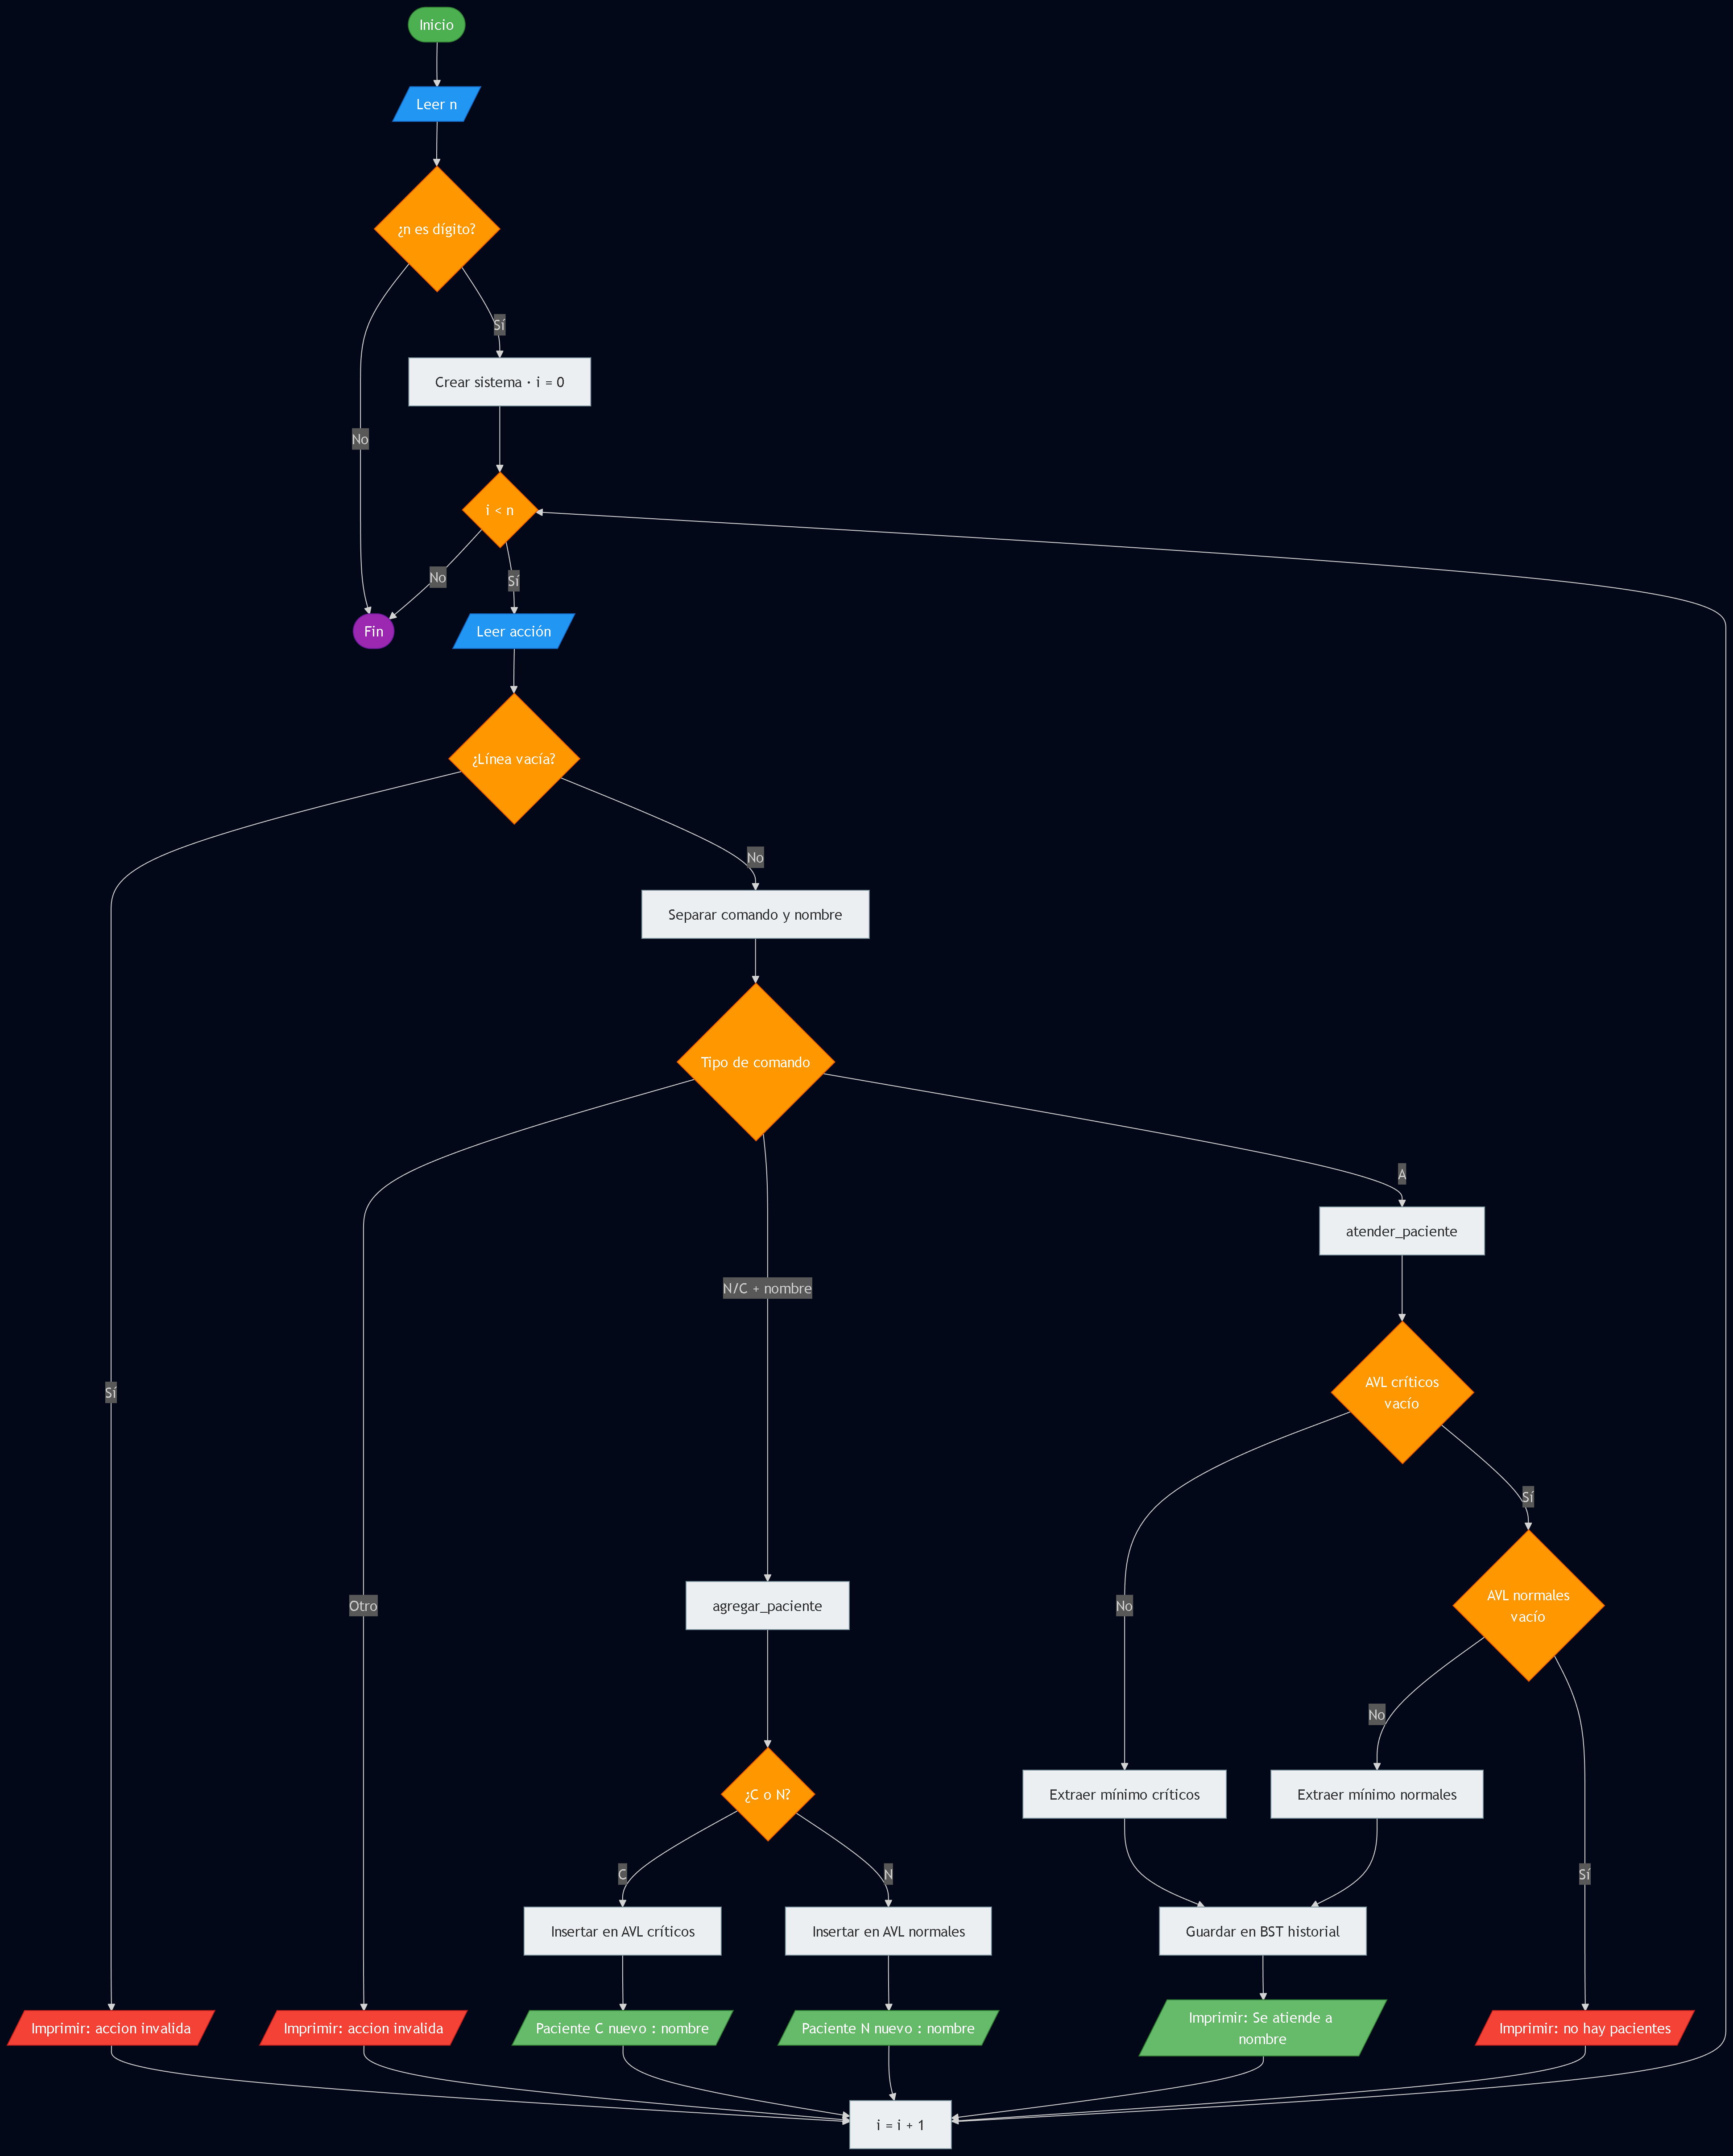

In [3]:
from IPython.display import Image
Image("flujo.png")

## 5) Diagrama de secuencia

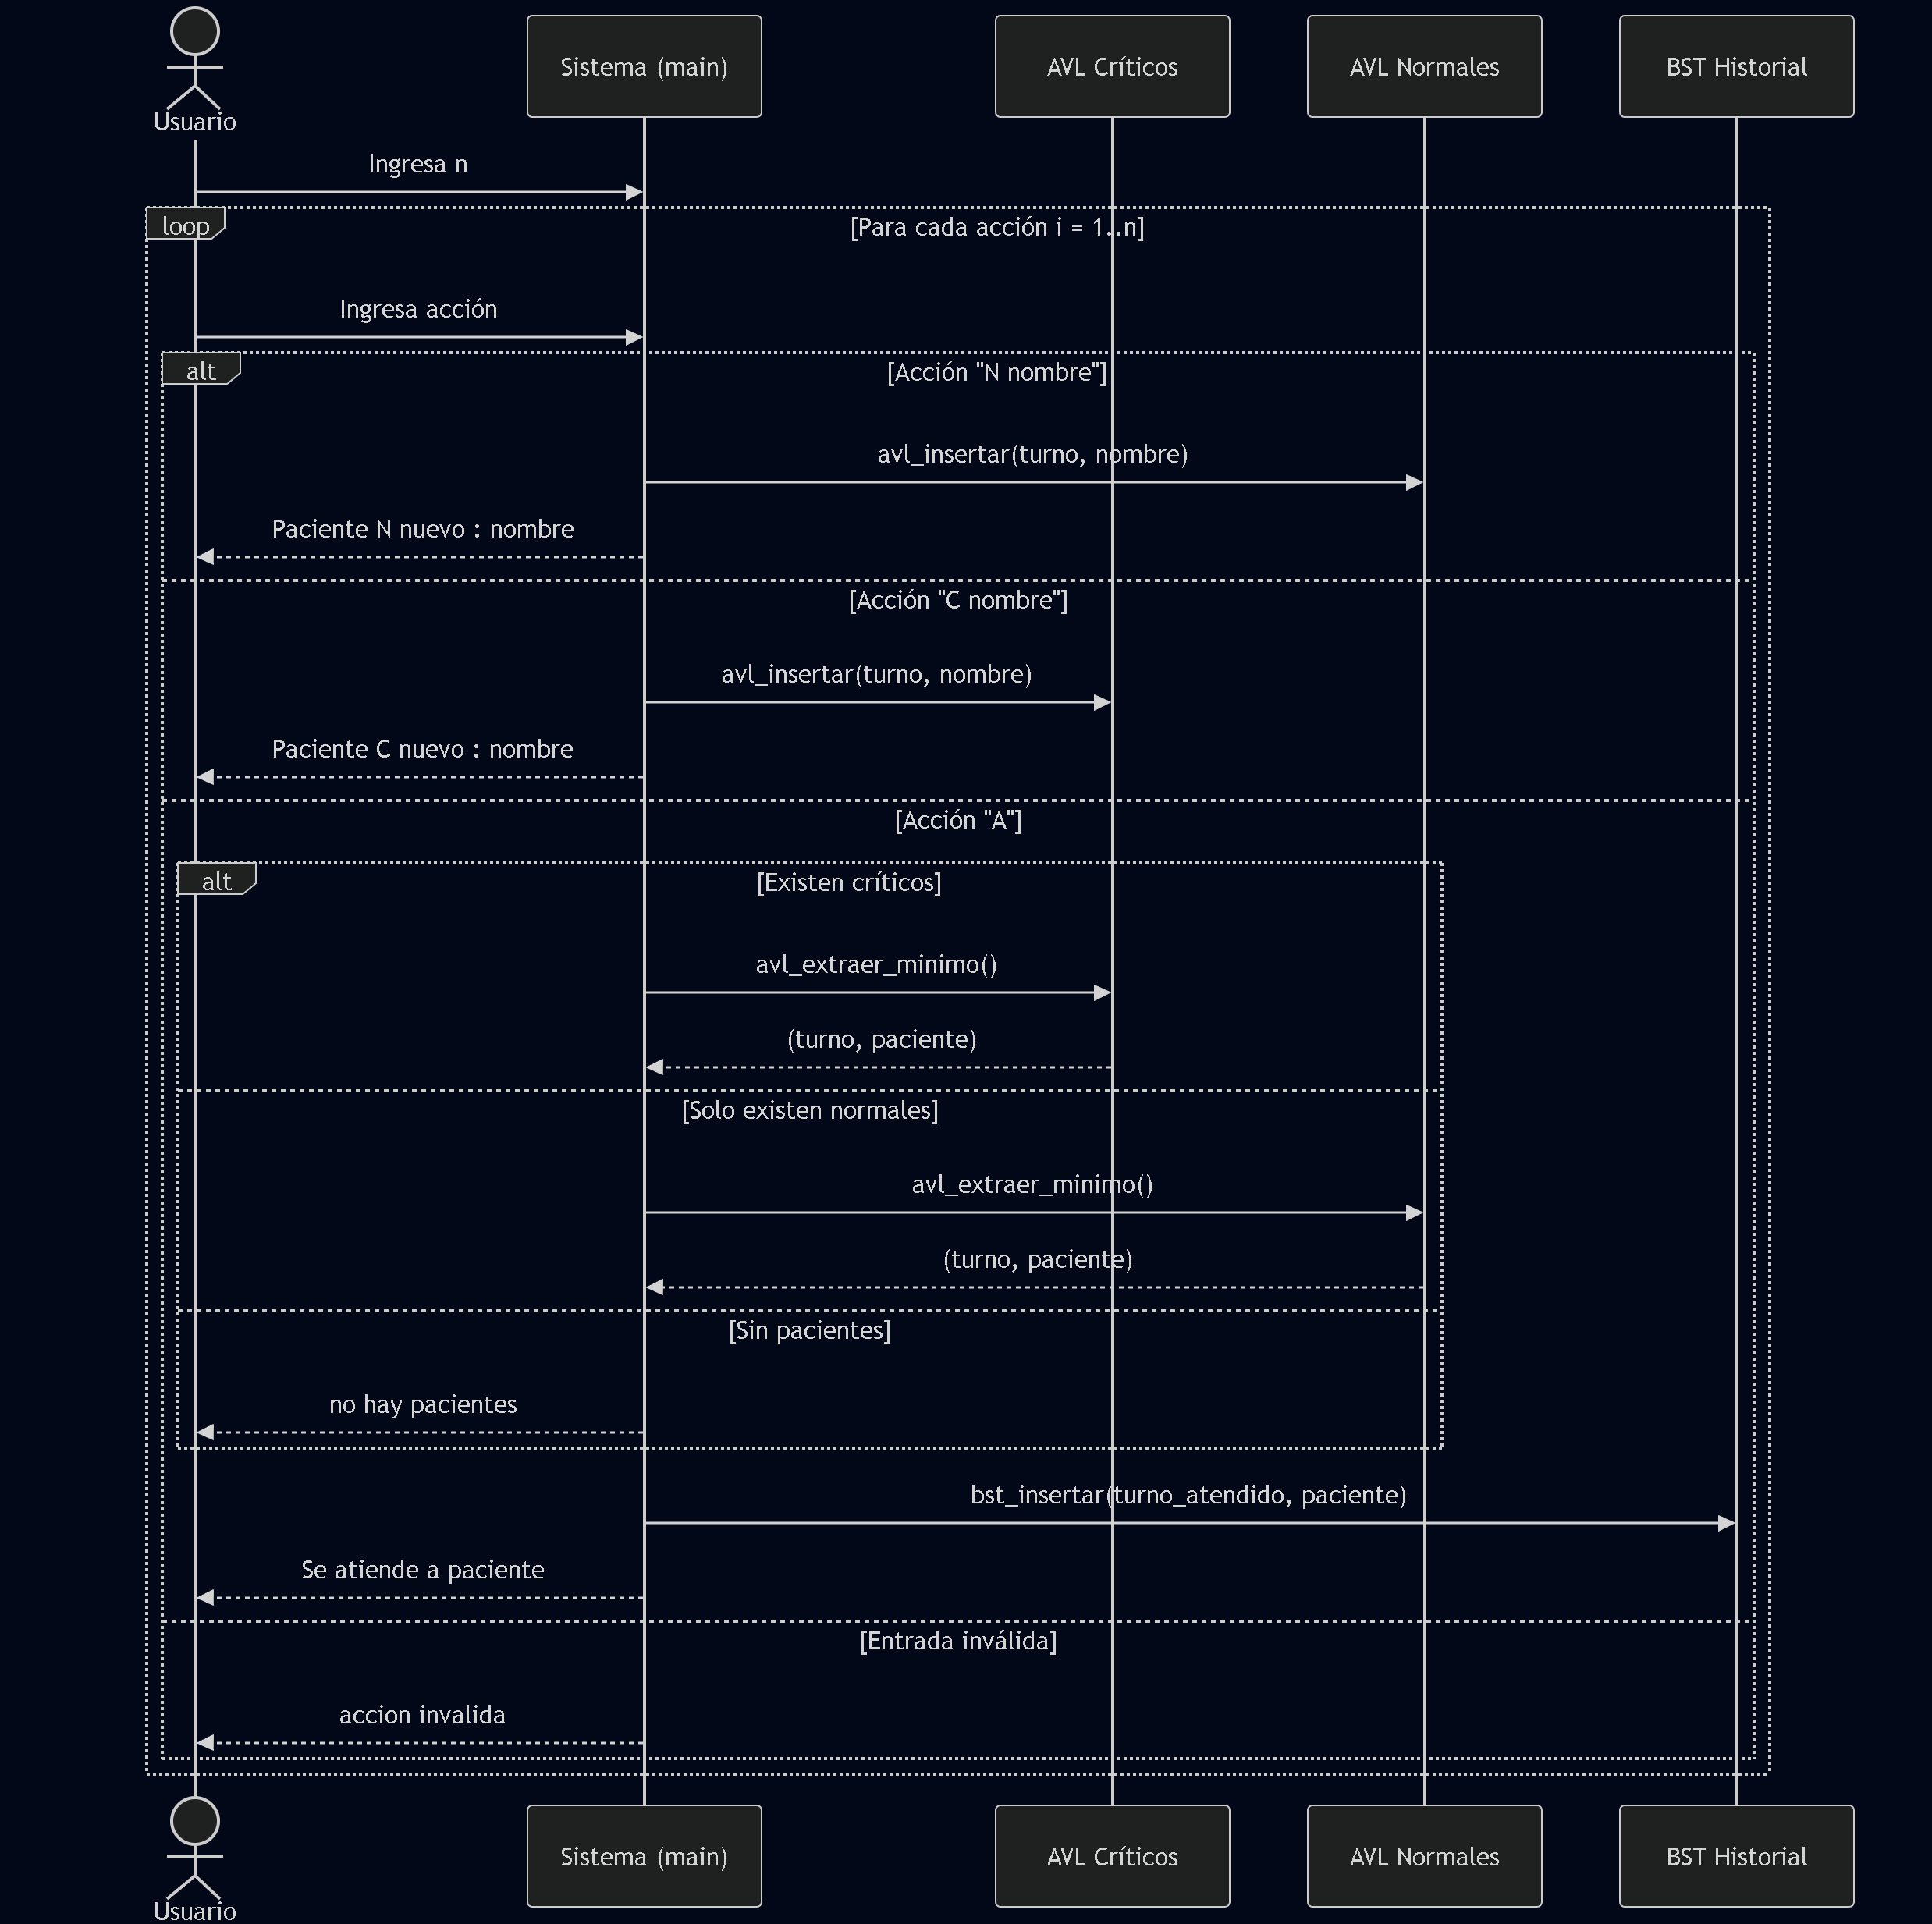

In [2]:
from IPython.display import Image
Image("secuencia.png")

## 6) Diagrama de casos de uso


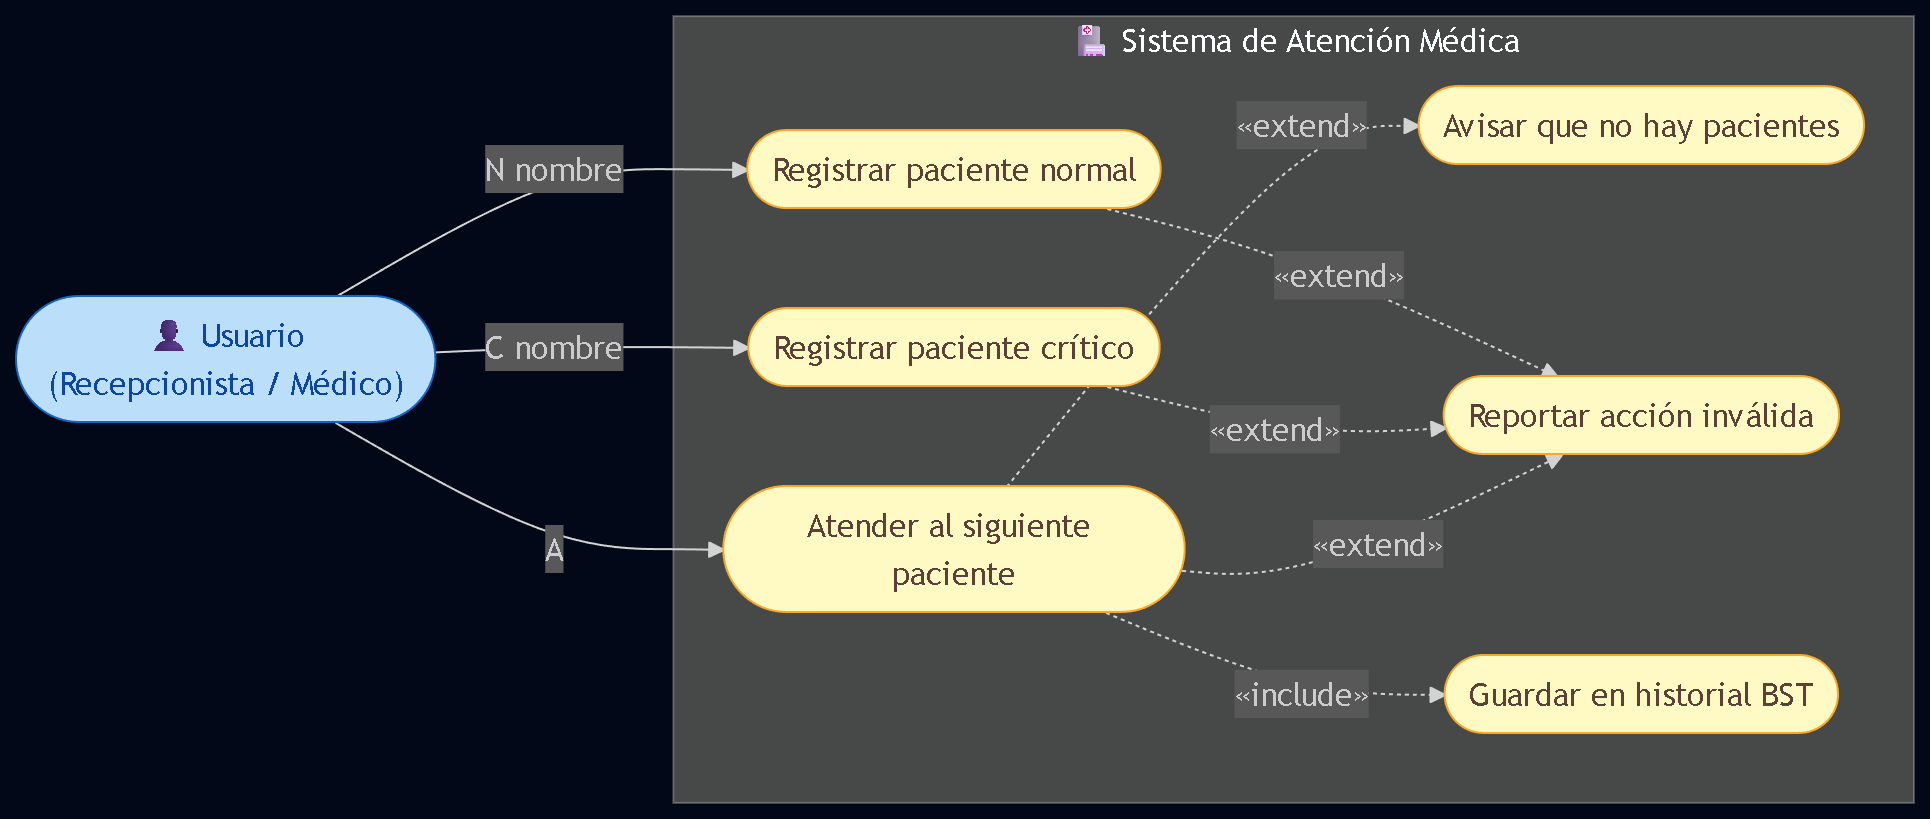

In [1]:
from IPython.display import Image
Image("caso.png")

## 7) Análisis de complejidad

### 7.1) Resumen del problema
El sistema procesa `n` acciones (`N nombre`, `C nombre`, `A`) usando dos árboles AVL para turnos en espera (críticos y normales) y un BST para historial de pacientes atendidos. Cada paciente recibe un turno creciente para preservar FIFO dentro de su categoría. Con AVL, inserción y extracción del mínimo se mantienen en $O(\log n)$, evitando el costo lineal de desplazar elementos de una lista.

### 7.2) Tabla compacta de complejidad

| Componente | Operación principal | Tiempo | Espacio adicional |
|---|---|---|---|
| `BST` | `insertar`, `buscar`, `eliminar` | $O(h)$ | $O(h)$ recursión |
| `BST` | `obtener_minimo`, `inorden` | $O(h)$ / $O(n)$ | $O(h)$ / $O(n)$ |
| `AVL` | `insertar`, `buscar`, `extraer_minimo` | $O(\log n)$ | $O(\log n)$ recursión |
| `AVL` | rotaciones (`izq`, `der`) | $O(1)$ | $O(1)$ |
| `sistema` | `agregar_paciente` | $O(\log n)$ | $O(1)$ |
| `sistema` | `atender_paciente` | $O(\log n)$ | $O(1)$ |
| `main` | Procesar `n` acciones | $O(n\log n)$ | $O(n)$ |

Donde `h` es la altura del árbol; en AVL, `h = O(\log n)`.

### 7.3) Complejidad total

Sea `n` el número total de acciones. Cada alta o atención realiza a lo sumo una inserción o extracción en AVL.

$$
T(n)=\sum_{i=1}^{n} O(\log i)=O(n\log n)
$$

| Escenario | Complejidad temporal | Complejidad espacial |
|---|---|---|
| Mejor caso (muchas acciones `A` con colas vacías) | $\Theta(n)$ | $\Theta(1)$ |
| Peor caso (muchas altas y atenciones) | $\Theta(n\log n)$ | $\Theta(n)$ |
| Caso promedio | $O(n\log n)$ | $O(n)$ |


### 7.4) Gráficas mejor/peor caso

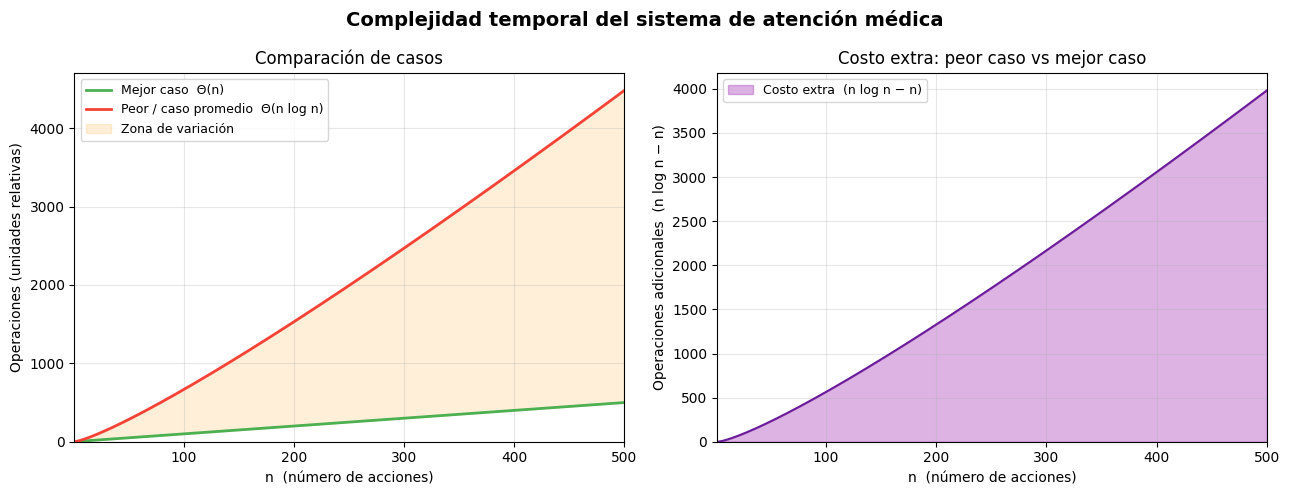

In [4]:
from IPython.display import Image
Image("casos.png")

### 7.5) Conclusión
La migración de colas lineales a AVL permite pasar de un peor caso cuadrático $O(n^2)$ a $O(n\log n)$ para el procesamiento completo. Se mantiene la prioridad de críticos sobre normales y se preserva FIFO dentro de cada categoría mediante turnos crecientes. El uso de BST para historial facilita consultas ordenadas y auditoría de pacientes atendidos.


## 8) Tests
Conjunto de pruebas propuesto para validar el sistema con BST/AVL:

### **Escenario 1: Prioridad de Triage (C sobre N)**
Descripción: valida que pacientes críticos salgan primero, manteniendo FIFO dentro de cada categoría.

**Entrada:**
4
N Carlos
C Amanda
A
A

**Resultado Esperado:**
Paciente N nuevo : Carlos
Paciente C nuevo : Amanda
Se atiende a Amanda
Se atiende a Carlos

### **Escenario 2: FIFO en misma prioridad**
Descripción: asegura orden de llegada entre pacientes normales almacenados en AVL por turno.

**Entrada:**
5
N Juan
N Pedro
N Maria
A
A

**Resultado Esperado:**
Paciente N nuevo : Juan
Paciente N nuevo : Pedro
Paciente N nuevo : Maria
Se atiende a Juan
Se atiende a Pedro

### **Escenario 3: Sin pacientes en espera**
Descripción: verifica respuesta correcta cuando no hay pacientes para atender.

**Entrada:**
3
C Urgente
A
A

**Resultado Esperado:**
Paciente C nuevo : Urgente
Se atiende a Urgente
no hay pacientes

### **Escenario 4: Entradas inválidas**
Descripción: valida robustez ante comandos mal formados o desconocidos.

**Entrada:**
6
N
X Pepe

C
A

**Resultado Esperado:**
accion invalida
accion invalida
accion invalida
accion invalida
no hay pacientes

## 9) Código funcional
Implementación completa del laboratorio con:

- Estructura `BST` para historial y consultas ordenadas.
- Estructura `AVL` para colas de espera optimizadas por turno.
- Sistema de atención médica con prioridad de críticos.
- Lectura de `n` acciones por entrada estándar.
- Salida exacta según el formato solicitado.
- Manejo robusto de entradas inválidas sin detener el programa.

In [ ]:
# ─────────────────────────────────────────────
# Parte 1: BST (árbol binario de búsqueda)
# ─────────────────────────────────────────────

def bst_crear():
    return {'raiz': None, 'tam': 0}

def bst_esta_vacio(arbol):
    return arbol['raiz'] is None

def bst_tamaño(arbol):
    return arbol['tam']

def _bst_insertar_rec(nodo, clave, valor):
    if nodo is None:
        return {'clave': clave, 'valor': valor, 'izq': None, 'der': None}, True
    if clave < nodo['clave']:
        nodo['izq'], nuevo = _bst_insertar_rec(nodo['izq'], clave, valor)
        return nodo, nuevo
    if clave > nodo['clave']:
        nodo['der'], nuevo = _bst_insertar_rec(nodo['der'], clave, valor)
        return nodo, nuevo
    nodo['valor'] = valor
    return nodo, False

def bst_insertar(arbol, clave, valor):
    arbol['raiz'], insertado = _bst_insertar_rec(arbol['raiz'], clave, valor)
    if insertado:
        arbol['tam'] += 1

def bst_buscar(arbol, clave):
    actual = arbol['raiz']
    while actual is not None:
        if clave < actual['clave']:
            actual = actual['izq']
        elif clave > actual['clave']:
            actual = actual['der']
        else:
            return actual['valor']
    return None

def bst_obtener_minimo(arbol):
    if arbol['raiz'] is None:
        return None
    nodo = arbol['raiz']
    while nodo['izq'] is not None:
        nodo = nodo['izq']
    return nodo['clave'], nodo['valor']

def _bst_eliminar_rec(nodo, clave):
    if nodo is None:
        return None, False
    if clave < nodo['clave']:
        nodo['izq'], eliminado = _bst_eliminar_rec(nodo['izq'], clave)
        return nodo, eliminado
    if clave > nodo['clave']:
        nodo['der'], eliminado = _bst_eliminar_rec(nodo['der'], clave)
        return nodo, eliminado
    if nodo['izq'] is None:
        return nodo['der'], True
    if nodo['der'] is None:
        return nodo['izq'], True
    sucesor = nodo['der']
    while sucesor['izq'] is not None:
        sucesor = sucesor['izq']
    nodo['clave'], nodo['valor'] = sucesor['clave'], sucesor['valor']
    nodo['der'], _ = _bst_eliminar_rec(nodo['der'], sucesor['clave'])
    return nodo, True

def bst_eliminar(arbol, clave):
    arbol['raiz'], eliminado = _bst_eliminar_rec(arbol['raiz'], clave)
    if eliminado:
        arbol['tam'] -= 1
    return eliminado

def bst_extraer_minimo(arbol):
    minimo = bst_obtener_minimo(arbol)
    if minimo is None:
        return None
    bst_eliminar(arbol, minimo[0])
    return minimo

def _bst_inorden_rec(nodo, resultado):
    if nodo is None:
        return
    _bst_inorden_rec(nodo['izq'], resultado)
    resultado.append((nodo['clave'], nodo['valor']))
    _bst_inorden_rec(nodo['der'], resultado)

def bst_inorden(arbol):
    resultado = []
    _bst_inorden_rec(arbol['raiz'], resultado)
    return resultado


# ─────────────────────────────────────────────
# Parte 2: AVL (árbol AVL auto-balanceado)
# ─────────────────────────────────────────────

def avl_crear():
    return {'raiz': None, 'tam': 0}

def avl_esta_vacio(arbol):
    return arbol['raiz'] is None

def avl_tamaño(arbol):
    return arbol['tam']

def _avl_altura(nodo):
    return 0 if nodo is None else nodo['altura']

def _avl_actualizar_altura(nodo):
    nodo['altura'] = 1 + max(_avl_altura(nodo['izq']), _avl_altura(nodo['der']))

def _avl_factor_balance(nodo):
    return _avl_altura(nodo['izq']) - _avl_altura(nodo['der'])

def _avl_rotar_derecha(y):
    x = y['izq']
    t2 = x['der']
    x['der'] = y
    y['izq'] = t2
    _avl_actualizar_altura(y)
    _avl_actualizar_altura(x)
    return x

def _avl_rotar_izquierda(x):
    y = x['der']
    t2 = y['izq']
    y['izq'] = x
    x['der'] = t2
    _avl_actualizar_altura(x)
    _avl_actualizar_altura(y)
    return y

def _avl_rebalancear(nodo):
    _avl_actualizar_altura(nodo)
    fb = _avl_factor_balance(nodo)
    if fb > 1:
        if _avl_factor_balance(nodo['izq']) < 0:
            nodo['izq'] = _avl_rotar_izquierda(nodo['izq'])
        return _avl_rotar_derecha(nodo)
    if fb < -1:
        if _avl_factor_balance(nodo['der']) > 0:
            nodo['der'] = _avl_rotar_derecha(nodo['der'])
        return _avl_rotar_izquierda(nodo)
    return nodo

def _avl_insertar_rec(nodo, clave, valor):
    if nodo is None:
        return {'clave': clave, 'valor': valor, 'izq': None, 'der': None, 'altura': 1}, True
    if clave < nodo['clave']:
        nodo['izq'], nuevo = _avl_insertar_rec(nodo['izq'], clave, valor)
    elif clave > nodo['clave']:
        nodo['der'], nuevo = _avl_insertar_rec(nodo['der'], clave, valor)
    else:
        nodo['valor'] = valor
        return nodo, False
    nodo = _avl_rebalancear(nodo)
    return nodo, nuevo

def avl_insertar(arbol, clave, valor):
    arbol['raiz'], insertado = _avl_insertar_rec(arbol['raiz'], clave, valor)
    if insertado:
        arbol['tam'] += 1

def avl_buscar(arbol, clave):
    actual = arbol['raiz']
    while actual is not None:
        if clave < actual['clave']:
            actual = actual['izq']
        elif clave > actual['clave']:
            actual = actual['der']
        else:
            return actual['valor']
    return None

def avl_obtener_minimo(arbol):
    if arbol['raiz'] is None:
        return None
    nodo = arbol['raiz']
    while nodo['izq'] is not None:
        nodo = nodo['izq']
    return nodo['clave'], nodo['valor']

def _avl_extraer_minimo_rec(nodo):
    if nodo['izq'] is None:
        return nodo['der'], (nodo['clave'], nodo['valor'])
    nodo['izq'], minimo = _avl_extraer_minimo_rec(nodo['izq'])
    nodo = _avl_rebalancear(nodo)
    return nodo, minimo

def avl_extraer_minimo(arbol):
    if arbol['raiz'] is None:
        return None
    arbol['raiz'], minimo = _avl_extraer_minimo_rec(arbol['raiz'])
    arbol['tam'] -= 1
    return minimo


# ─────────────────────────────────────────────
# Parte 3: Sistema de atención médica
# ─────────────────────────────────────────────

def sistema_crear():
    return {
        'arbol_criticos': avl_crear(),
        'arbol_normales': avl_crear(),
        'historial': bst_crear(),
        'turno_llegada': 0,
        'turno_atendido': 0,
    }

def agregar_paciente(sistema, tipo, nombre):
    nombre = nombre.strip()
    if not nombre:
        return "accion invalida"
    sistema['turno_llegada'] += 1
    if tipo == "C":
        avl_insertar(sistema['arbol_criticos'], sistema['turno_llegada'], nombre)
        return f"Paciente C nuevo : {nombre}"
    if tipo == "N":
        avl_insertar(sistema['arbol_normales'], sistema['turno_llegada'], nombre)
        return f"Paciente N nuevo : {nombre}"
    return "accion invalida"

def atender_paciente(sistema):
    if not avl_esta_vacio(sistema['arbol_criticos']):
        _, paciente = avl_extraer_minimo(sistema['arbol_criticos'])
    elif not avl_esta_vacio(sistema['arbol_normales']):
        _, paciente = avl_extraer_minimo(sistema['arbol_normales'])
    else:
        return "no hay pacientes"
    sistema['turno_atendido'] += 1
    bst_insertar(sistema['historial'], sistema['turno_atendido'], paciente)
    return f"Se atiende a {paciente}"

def historial_en_orden(sistema):
    return [valor for _, valor in bst_inorden(sistema['historial'])]


# ─────────────────────────────────────────────
# Parte 4: Función principal
# ─────────────────────────────────────────────

def main():
    sistema = sistema_crear()
    try:
        linea_n = input().strip()
    except EOFError:
        return
    if not linea_n.isdigit():
        return
    n = int(linea_n)
    for _ in range(n):
        try:
            linea = input().strip()
        except EOFError:
            break
        if not linea:
            print("accion invalida")
            continue
        partes = linea.split(maxsplit=1)
        comando = partes[0]
        if comando == "A" and len(partes) == 1:
            print(atender_paciente(sistema))
        elif comando in ("N", "C") and len(partes) == 2 and partes[1].strip():
            print(agregar_paciente(sistema, comando, partes[1]))
        else:
            print("accion invalida")

main()


## 10) Tests aplicados (extras)
Pruebas adicionales ejecutadas sobre la lógica del sistema:

1. **Prueba extra n=20 (secuencia mixta)**
- Se alternan inserciones N/C y atenciones A.
- Se valida que nunca se atienda normal si existe crítico pendiente.

2. **Prueba extra n=30 (estrés básico)**
- Se ejecutan múltiples encolados y atenciones.
- Se valida estabilidad FIFO dentro de cada prioridad.

3. **Prueba de validación (acción inválida / entrada incorrecta)**
- Se prueba comando no permitido y entrada vacía.
- Se espera `accion invalida` sin detener el programa.

A continuación se muestran pruebas unitarias directas (asserts).

In [ ]:
# Pruebas extra de funcionalidad y estructura

def _altura_y_balance_ok(nodo):
    if nodo is None:
        return 0, True
    h_izq, ok_izq = _altura_y_balance_ok(nodo['izq'])
    h_der, ok_der = _altura_y_balance_ok(nodo['der'])
    ok_actual = abs(h_izq - h_der) <= 1 and nodo['altura'] == 1 + max(h_izq, h_der)
    return 1 + max(h_izq, h_der), ok_izq and ok_der and ok_actual


def prueba_prioridad_y_fifo():
    sistema = sistema_crear()
    assert agregar_paciente(sistema, "N", "Carlos") == "Paciente N nuevo : Carlos"
    assert agregar_paciente(sistema, "C", "Amanda") == "Paciente C nuevo : Amanda"
    assert agregar_paciente(sistema, "N", "Pedro")  == "Paciente N nuevo : Pedro"
    assert agregar_paciente(sistema, "C", "Marta")  == "Paciente C nuevo : Marta"

    # Críticos primero, respetando FIFO interno
    assert atender_paciente(sistema) == "Se atiende a Amanda"
    assert atender_paciente(sistema) == "Se atiende a Marta"
    # Luego normales en FIFO
    assert atender_paciente(sistema) == "Se atiende a Carlos"
    assert atender_paciente(sistema) == "Se atiende a Pedro"
    assert atender_paciente(sistema) == "no hay pacientes"

    assert historial_en_orden(sistema) == ["Amanda", "Marta", "Carlos", "Pedro"]
    print("Prueba prioridad/FIFO: OK")


def prueba_balance_avl_intenso():
    arbol = avl_crear()
    for i in range(1, 101):
        avl_insertar(arbol, i, f"P{i}")

    _, balance_ok = _altura_y_balance_ok(arbol['raiz'])
    assert balance_ok, "El AVL perdio balance despues de inserciones"
    assert avl_tamaño(arbol) == 100

    # Extracciones del mínimo deben salir ordenadas
    for i in range(1, 101):
        clave, valor = avl_extraer_minimo(arbol)
        assert clave == i
        assert valor == f"P{i}"

    assert avl_esta_vacio(arbol)
    print("Prueba balance AVL intensivo: OK")


def prueba_bst_historial():
    arbol = bst_crear()
    datos = [(5, "Ana"), (2, "Luis"), (8, "Marta"), (1, "Pedro"), (3, "Laura")]
    for k, v in datos:
        bst_insertar(arbol, k, v)

    assert bst_buscar(arbol, 3) == "Laura"
    assert bst_buscar(arbol, 9) is None
    assert bst_obtener_minimo(arbol) == (1, "Pedro")

    assert bst_eliminar(arbol, 2) is True
    assert bst_buscar(arbol, 2) is None
    assert bst_tamaño(arbol) == 4
    assert [k for k, _ in bst_inorden(arbol)] == [1, 3, 5, 8]
    print("Prueba BST historial: OK")


def prueba_entradas_invalidas():
    sistema = sistema_crear()
    assert agregar_paciente(sistema, "X", "Test") == "accion invalida"
    assert agregar_paciente(sistema, "N", "   ")  == "accion invalida"
    assert atender_paciente(sistema) == "no hay pacientes"

    agregar_paciente(sistema, "C", "Unico")
    assert atender_paciente(sistema) == "Se atiende a Unico"
    assert atender_paciente(sistema) == "no hay pacientes"
    print("Prueba entradas invalidas: OK")


prueba_prioridad_y_fifo()
prueba_balance_avl_intenso()
prueba_bst_historial()
prueba_entradas_invalidas()


Prueba prioridad/FIFO: OK
Prueba balance AVL intensivo: OK
Prueba BST historial: OK
Prueba entradas invalidas: OK
